In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_updated.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/S2/SSRtransforms_all.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

2026-03-25 10:10:26.277645: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 10:10:26.776851: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-25 10:10:28.479834: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 10:10:28.484378: I external/local_xla/xla/tsl/cuda/cudart

In [2]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

# Bright

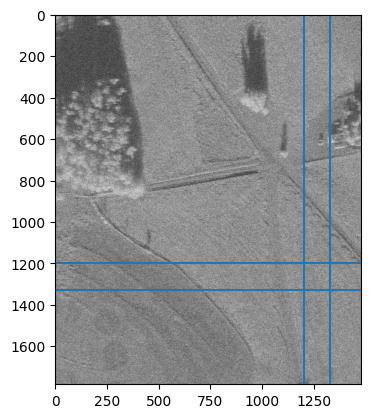

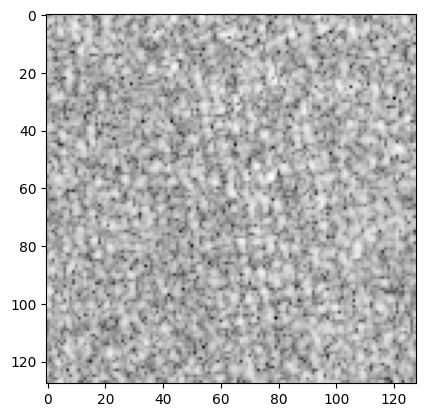

In [3]:
xk = 1200
yk = 1200

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [4]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
meas_ds_path = [meas_ds.samples[i][0] for i in range(len(meas_ds))]
clutter_cache1 = {file: (os.path.join(clutter_dir, 'HB06158'), 1200, 1200) for file in meas_ds_path}

In [6]:
meas_ds_s2_1_no_clip = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache1), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_s2_1_og = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging_og(clutter_cache1), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_s2_1_clip = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging_clipped(clutter_cache1), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [18]:
meas_ds_lst = [meas_ds_s2_1_no_clip, meas_ds_s2_1_og, meas_ds_s2_1_clip]

for i in range(len(meas_ds_lst[0])):
    fig = plt.figure(figsize = (15, 5))

    tensor, label = meas_ds_lst[0][i]
    class_name = meas_ds_lst[0].classes[label]
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(meas_ds_lst[0][i][0][0], cmap = "grey")
    ax1.set_title("no clip")

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(meas_ds_lst[1][i][0][0], cmap = "grey")
    ax2.set_title("OG")

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.imshow(meas_ds_lst[2][i][0][0], cmap = "grey")
    ax3.set_title("clipped")
    # print(os.path.join(workspace, "images", "nc_og_clipped", f"img_{i}_{class_name}.jpg"))
    fig.savefig(os.path.join(workspace, "images", "nc_og_clipped", "Bright", f"img_{i}_{class_name}.jpg"))
    plt.close(fig)

# Dark

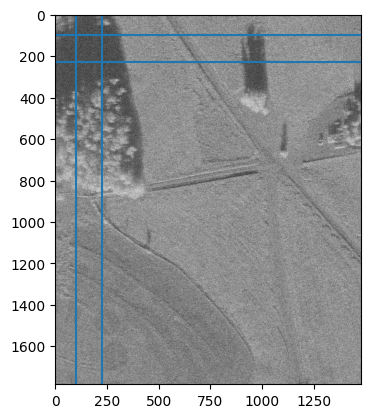

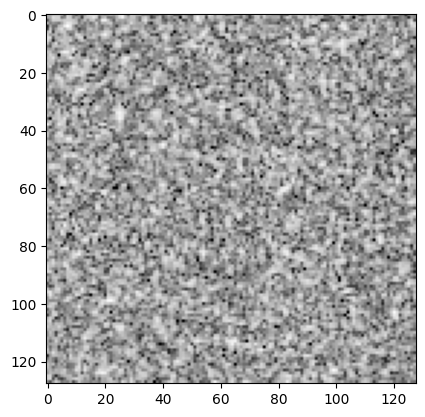

In [19]:
xk = 100
yk = 100

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [20]:
clutter_cache2 = {file: (os.path.join(clutter_dir, 'HB06158'), 100, 100) for file in meas_ds_path}

In [21]:
meas_ds_s2_2_no_clip = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache2), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_s2_2_og = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging_og(clutter_cache2), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_s2_2_clip = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging_clipped(clutter_cache2), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [22]:
meas_ds_lst = [meas_ds_s2_2_no_clip, meas_ds_s2_2_og, meas_ds_s2_2_clip]

for i in range(len(meas_ds_lst[0])):
    fig = plt.figure(figsize = (15, 5))

    tensor, label = meas_ds_lst[0][i]
    class_name = meas_ds_lst[0].classes[label]
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(meas_ds_lst[0][i][0][0], cmap = "grey")
    ax1.set_title("no clip")

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(meas_ds_lst[1][i][0][0], cmap = "grey")
    ax2.set_title("OG")

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.imshow(meas_ds_lst[2][i][0][0], cmap = "grey")
    ax3.set_title("clipped")
    # print(os.path.join(workspace, "images", "nc_og_clipped", f"img_{i}_{class_name}.jpg"))
    fig.savefig(os.path.join(workspace, "images", "nc_og_clipped", "Dark", f"img_{i}_{class_name}.jpg"))
    plt.close(fig)

# Mixed

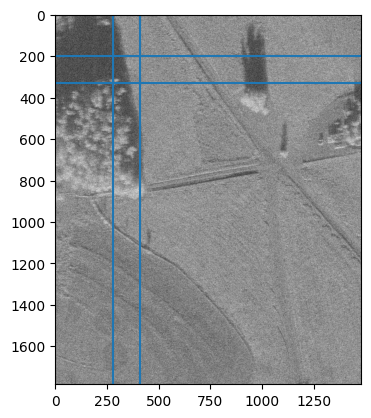

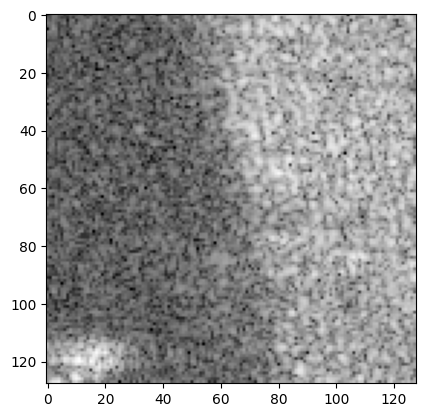

In [23]:
xk = 280
yk = 200

img = LogMapping(c = 1000.0)(Magnitude()(read_mstar_clutter_complex(os.path.join(clutter_dir, 'HB06158'))))
plt.imshow(img, cmap = "grey")
plt.axvline(x = xk)
plt.axvline(x = xk + 128)
plt.axhline(y = yk)
plt.axhline(y = yk + 128)
plt.show()
plt.imshow(img[yk: yk+128, xk: xk+128], cmap = "grey")
plt.show()

In [24]:
clutter_cache3 = {file: (os.path.join(clutter_dir, 'HB06158'), 200, 280) for file in meas_ds_path}

In [25]:
meas_ds_s2_3_no_clip = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_s2_3_og = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging_og(clutter_cache3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds_s2_3_clip = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging_clipped(clutter_cache3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [26]:
meas_ds_lst = [meas_ds_s2_3_no_clip, meas_ds_s2_3_og, meas_ds_s2_3_clip]

for i in range(len(meas_ds_lst[0])):
    fig = plt.figure(figsize = (15, 5))

    tensor, label = meas_ds_lst[0][i]
    class_name = meas_ds_lst[0].classes[label]
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.imshow(meas_ds_lst[0][i][0][0], cmap = "grey")
    ax1.set_title("no clip")

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.imshow(meas_ds_lst[1][i][0][0], cmap = "grey")
    ax2.set_title("OG")

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.imshow(meas_ds_lst[2][i][0][0], cmap = "grey")
    ax3.set_title("clipped")
    # print(os.path.join(workspace, "images", "nc_og_clipped", f"img_{i}_{class_name}.jpg"))
    fig.savefig(os.path.join(workspace, "images", "nc_og_clipped", "Mixed", f"img_{i}_{class_name}.jpg"))
    plt.close(fig)